# Neutrino multisim systematic covariances (notebook production)

Compute per-knob and **total** (multiplied universe weights) rate covariances for final-selection MC,
for **MCstat**, **Flux**, and/or **G4**, matching the logic of ``syst_multisim_chunk.py`` /
``syst_multisim_aggregate.py``. Writes ``MCstat/``, ``Flux/``, and ``G4/`` NPZs under the
legacy ``syst_disk_layout`` tree.

Set ``SYST_TYPES`` below (or ``MULTISIM_SYST_TYPES`` env) to choose which categories to run;
each category loads from its own ``dataset_locations.MULTISIM_SYST_GLOBS_FINAL`` directory.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from datetime import datetime
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
from pandas.errors import PerformanceWarning
from tqdm import tqdm

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')

from pyanalib.split_df_helpers import *
from pyanalib.covariance import get_covariance_matrix
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

from analysis_village.numucc_1p0pi.variable_configs import VariableConfig, var_configs_measurement
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.categories import get_topo_category
from analysis_village.numucc_1p0pi.selection_framework import multicol_resolve_column_key
from analysis_village.numucc_1p0pi.dataset_locations import MULTISIM_SYST_GLOBS_FINAL
from analysis_village.numucc_1p0pi.syst_multisim_common import (
    NEUTRINO_SYST_ORDER,
    drop_bad_flux_knob_weights,
    drop_bad_g4_knob_weights,
    drop_bad_genie_weights,
    flux_mc_knob_names,
    g4_mc_knob_names,
    parse_neutrino_syst_type_csv,
    save_neutrino_multisim_npzs,
    syst_key_for_name,
)
from analysis_village.numucc_1p0pi.syst_disk_layout import category_out_dir, normalized_root

warnings.filterwarnings('ignore', category=PerformanceWarning)
plt.style.use('presentation.mplstyle')


def _ts():
    return datetime.now().strftime('%H:%M:%S')


def _log(msg):
    print(f'[{_ts()}] {msg}', flush=True)

In [3]:
var_configs = var_configs_measurement

In [4]:
# _syst_types_env = os.environ.get('MULTISIM_SYST_TYPES', 'MCstat,Flux,G4')
_syst_types_env = os.environ.get('MULTISIM_SYST_TYPES', 'GENIE')
SYST_TYPES = parse_neutrino_syst_type_csv(_syst_types_env)
_log(f'systematic categories: {SYST_TYPES}')


def multisim_search_dir(syst_name: str) -> str:
    """Parent directory of ``MULTISIM_SYST_GLOBS_FINAL[syst_name]`` (merged_perTPC)."""
    if syst_name not in MULTISIM_SYST_GLOBS_FINAL:
        raise KeyError(f'no glob for {syst_name!r}; edit MULTISIM_SYST_GLOBS_FINAL')
    return str(Path(MULTISIM_SYST_GLOBS_FINAL[syst_name]).parent)

[13:52:20] systematic categories: ('GENIE',)


In [5]:
dirname = multisim_search_dir("GENIE")
dirname

'/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_23_235202__sel_mup-wgts_genie_slim/perTPC'

In [6]:
from pyanalib.split_df_helpers_new import *


evtdf_raw = {}
nudf_raw = {}
for sn in SYST_TYPES:
    dirname = multisim_search_dir(sn)
    dirname = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_030314__sel_mup-wgts_genie_MEC/merged_perTPC"
    _log(f'loading {sn} MC from {dirname} ...')
    t_load = time.time()
    dfs = dfs_from_dir(
        search_dir=dirname,
        filename_str='sel_mup',
        keys2load=['hdr', 'evt', 'mcnu'],
        n_max_concat=999,
    )
    if 'evt' not in dfs:
        raise RuntimeError(f'no evt table for {sn} under {dirname}')
    evtdf_raw[sn] = dfs['evt']
    _log(f'  {sn}: {len(evtdf_raw[sn]):,} rows in {time.time() - t_load:.1f}s')

    if 'mcnu' in dfs:
        nudf_raw[sn] = dfs['mcnu']
        _log(f'  {sn}: {len(nudf_raw[sn]):,} rows in {time.time() - t_load:.1f}s')


[13:52:20] loading GENIE MC from /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_030314__sel_mup-wgts_genie_MEC/merged_perTPC ...
Found 19 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_030314__sel_mup-wgts_genie_MEC/merged_perTPC/2026_05_11_030314__sel_mup-wgts_genie_MEC_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_030314__sel_mup-wgts_genie_MEC/merged_perTPC/2026_05_11_030314__sel_mup-wgts_genie_MEC_merged_0001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_030314__sel_mup-wgts_genie_MEC/merged_perTPC/2026_05_11_030314__sel_mup-wgts_genie_MEC_merged_0002.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_030314__sel_mup-wgts_genie_MEC/merged_perTPC/2026_05_11_030314__sel_mup-wgts_genie_MEC_merged_0003.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_030314__sel_mup-wgts_genie_MEC/merged_perTPC/2026_05_11_030314__sel_mup-wgts_genie_MEC

100%|██████████| 19/19 [01:49<00:00,  5.78s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
[13:55:32]   GENIE: 74,249 rows in 191.6s
[13:55:32]   GENIE: 11,508,306 rows in 191.6s


In [7]:
def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    df['del_Tp_x'] = tki_reco['del_Tp_x']
    df['del_Tp_y'] = tki_reco['del_Tp_y']

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
    df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
    df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    n_before = len(df)
    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


evtdf_by_syst = {}
for sn in SYST_TYPES:
    _log(f'running evt_df_fixed for {sn} ...')
    t_fix = time.time()
    evtdf, n_evt_before_fv = evt_df_fixed(evtdf_raw[sn])
    evtdf_by_syst[sn] = evtdf
    _log(
        f'  {sn}: {len(evtdf):,} events after FV cut ({n_evt_before_fv:,} before) '
        f'in {time.time() - t_fix:.1f}s'
    )
    if 'topo_categ' in evtdf.columns:
        _log('  topo_categ counts: ' + evtdf.topo_categ.value_counts().to_dict().__repr__())


[13:55:32] running evt_df_fixed for GENIE ...
[13:55:32]   GENIE: 74,249 events after FV cut (74,249 before) in 0.2s
[13:55:32]   topo_categ counts: {1: 67813, 2: 2322, 3: 2151, 4: 1115, -1: 649, 0: 199}


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
def nu_df_fixed(df):
    # df.columns = pd.MultiIndex.from_tuples([tuple(["mc"] + list(c)) for c in df.columns])     # match # of column levels
    mc_mudf = df.mc.mu
    mc_pdf = df.mc.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    df['del_Tp_x'] = tki_mc['del_Tp_x']
    df['del_Tp_y'] = tki_mc['del_Tp_y']
    # df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
    # df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

    n_before = len(df)
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


nudf_by_syst = {}
for sn in SYST_TYPES:
    _log(f'running nu_df_fixed for {sn} ...')
    t_fix = time.time()
    nudf, n_nu_before_fv = nu_df_fixed(nudf_raw[sn])
    nudf_by_syst[sn] = nudf
    _log(
        f'  {sn}: {len(nudf):,} events after FV cut ({n_nu_before_fv:,} before) '
        f'in {time.time() - t_fix:.1f}s'
    )
    if 'topo_categ' in nudf.columns:
        _log('  topo_categ counts: ' + nudf.topo_categ.value_counts().to_dict().__repr__())


[13:55:32] running nu_df_fixed for GENIE ...
[13:55:39]   GENIE: 11,508,306 events after FV cut (11,508,306 before) in 6.4s
[13:55:39]   topo_categ counts: {0: 8122452, 3: 1666329, 4: 976910, 1: 408236, 2: 334379}


In [9]:
def syst_knob_names(syst_name: str) -> tuple[str, ...]:
    """Per-knob weight columns for Flux/G4; empty for bundled MCstat."""
    if syst_name == 'Flux':
        return flux_mc_knob_names('all')
    if syst_name == 'G4':
        return g4_mc_knob_names()
    return ()


def drop_bad_weights(evtdf, syst_name: str, knobs, n_univ: int):
    if syst_name == 'G4' and knobs:
        return drop_bad_g4_knob_weights(evtdf, knobs=knobs, n_univ=n_univ)
    if syst_name == 'GENIE':
        return drop_bad_genie_weights(evtdf, n_univ=n_univ)
    return evtdf


def resolve_bundled_syst_name(evtdf, syst_name: str):
    """Weight column root for ``get_univ_rates`` (MCstat layout variants)."""
    if syst_name == 'MCstat':
        for sk in (('mc', 'MCstat'), 'MCstat'):
            probe = sk + ('univ_0',) if isinstance(sk, tuple) else (sk, 'univ_0')
            if multicol_resolve_column_key(evtdf, probe) is not None:
                return sk
        return ('mc', 'MCstat')
    elif syst_name == 'GENIE':
        for sk in (('mc', 'GENIE'), 'GENIE'):
            probe = sk + ('univ_0',) if isinstance(sk, tuple) else (sk, 'univ_0')
            if multicol_resolve_column_key(evtdf, probe) is not None:
                return sk
        return ('mc', 'GENIE')
    return syst_key_for_name(syst_name)


for sn in SYST_TYPES:
    knobs = syst_knob_names(sn)
    if knobs:
        _log(f'{sn}: {len(knobs)} knobs; first={knobs[0]!r} ... last={knobs[-1]!r}')
        k0 = knobs[0]
        key0 = multicol_resolve_column_key(evtdf_by_syst[sn], ('mc', k0, 'univ_0'))
        _log(f'  weight probe knob={k0!r} univ_0 -> {key0!r}')
    else:
        sk = resolve_bundled_syst_name(evtdf_by_syst[sn], sn)
        probe = sk + ('univ_0',) if isinstance(sk, tuple) else (sk, 'univ_0')
        key0 = multicol_resolve_column_key(evtdf_by_syst[sn], probe)
        _log(f'{sn}: bundled weights; syst_name={sk!r} univ_0 -> {key0!r}')


[13:55:39] GENIE: bundled weights; syst_name=('mc', 'GENIE') univ_0 -> None


In [10]:
var_configs = [VariableConfig.tki_del_Tp()]

In [11]:
cov_type = 'xsec'
bkgd_subtract = True  # match syst_multisim_chunk.py (signal + bkgd-subtracted rate)
n_univ = 100

# --- progress / plotting controls ---
VERBOSE_UNIV_LOOP = True   # tqdm inside get_univ_rates
PLOT_UNIV_EVERY_N_KNOBS = 1   # universe hist for knob index 0,3,6,... (set 0 to disable)
PLOT_FRAC_UNC_EACH_VAR = True
PLOT_HEATMAP_FIRST_VAR = True  # cov_frac heatmap for first completed variable
SAVE_UNIV_HISTS = True  # write PNGs for every plot_univ_hists call

today_str = datetime.now().strftime('%Y%m%d')
SYST_DISK_ROOT = path.join(save_fig_base_dir, f'systematics-notebook-{today_str}')
os.makedirs(SYST_DISK_ROOT, exist_ok=True)


def univ_hist_save_name(sn, vsn, tag):
    """``<SYST_DISK_ROOT>/<sn>/<vsn>-<tag>-universes`` (no extension; plot_univ_hists adds fig_ext)."""
    cat_dir = category_out_dir(SYST_DISK_ROOT, sn)
    os.makedirs(cat_dir, exist_ok=True)
    return path.join(cat_dir, f'{vsn}-{tag}-universes')
_log('syst disk root: ' + normalized_root(SYST_DISK_ROOT))
_log(
    f'workload estimate: {len(SYST_TYPES)} syst x {len(var_configs)} vars x (knobs or bundled) x {n_univ} universes '
    f'(+ multiplied total per knob-var for Flux/G4)'
)



[13:55:39] syst disk root: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-20260526
[13:55:39] workload estimate: 1 syst x 1 vars x (knobs or bundled) x 100 universes (+ multiplied total per knob-var for Flux/G4)


In [14]:
evtdf.mc

E    baseline      time  bjorkenX  \
                                                                          
                                                                          
                                                                          
                                                                          
                                                                          
__ntuple entry rec.slc..index                                             
4        16    1               0.568495   86.894592  1.137640  0.641948   
0        12    0               0.526172   95.891487  0.944653  1.213891   
1        7     0               0.532423  127.366821  1.739319  1.478736   
         11    2               0.531989  124.316223  0.584061  1.291898   
11       5     0               1.164804   87.276703  1.411850  0.995876   
..                                  ...         ...       ...       ...   
374039   16    0               0.784297   90.779587  1.640677  0.867881   
374037   9     0               0.851652   96.113892  1.468308  0.883421   
374046   16    0               0.772583   83.245613  0.966969  0.791775   
374050   11    0               0.761455   80.633469  1.093767  0.555468   
374054   14    1               0.504470  120.079399  0.761877  0.472517   

                              inelasticityY        Q2         w  momentum  \
                                                                        x   
                                                                            
                                                                            
                                                                            
                                                                            
__ntuple entry rec.slc..index                                               
4        16    1                   0.417198  0.285908  1.020312 -0.000455   
0        12    0                   0.212082  0.254371  0.914739 -0.002549   
1        7     0                   0.288554  0.426612  0.862238 -0.000558   
         11    2                   0.362023  0.467224  0.880910  0.010736   
11       5     0                   0.240087  0.522979  0.940071  0.007594   
..                                      ...       ...       ...       ...   
374039   16    0                   0.301191  0.384983  0.969626 -0.002207   
374037   9     0                   0.255345  0.360758  0.963937  0.012847   
374046   16    0                   0.466162  0.535478  1.011134  0.021574   
374050   11    0                   0.492091  0.390847  1.092866  0.018430   
374054   14    1                   0.428521  0.191815  1.046755  0.008090   

                                                   ...  \
                                      y         z  ...   
                                                   ...   
                                                   ...   
                                                   ...   
                                                   ...   
__ntuple entry rec.slc..index                      ...   
4        16    1              -0.012921  0.568348  ...   
0        12    0              -0.000897  0.526165  ...   
1        7     0               0.001589  0.532420  ...   
         11    2              -0.001152  0.531879  ...   
11       5     0               0.010137  1.164735  ...   
..                                  ...       ...  ...   
374039   16    0              -0.008979  0.784243  ...   
374037   9     0              -0.000419  0.851555  ...   
374046   16    0              -0.001579  0.772280  ...   
374050   11    0              -0.004179  0.761220  ...   
374054   14    1              -0.007833  0.504344  ...   

                              GENIEReWeight_SBN_v1_multisim_NormNCMEC          \
                                                              univ_97 univ_98   
                                                                                
            

getting 100 universes for ('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC') uncertainty on the event rate


Getting universes: 100%|██████████| 100/100 [00:04<00:00, 24.43it/s]


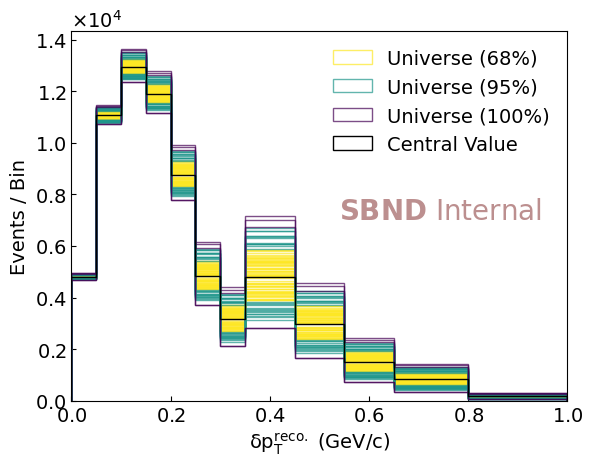

getting 100 universes for ('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC') uncertainty on the xsec


Getting universes: 100%|██████████| 100/100 [00:06<00:00, 16.63it/s]


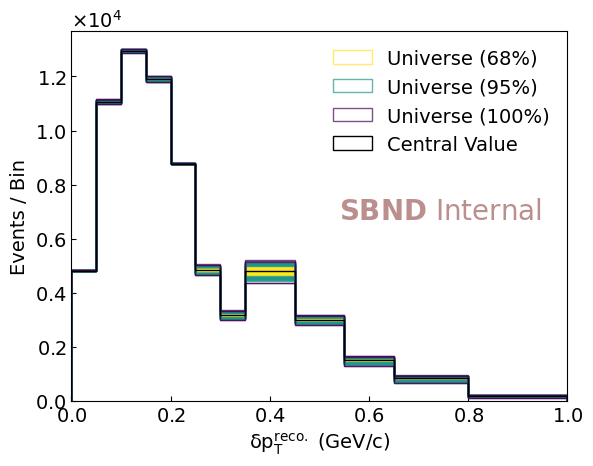

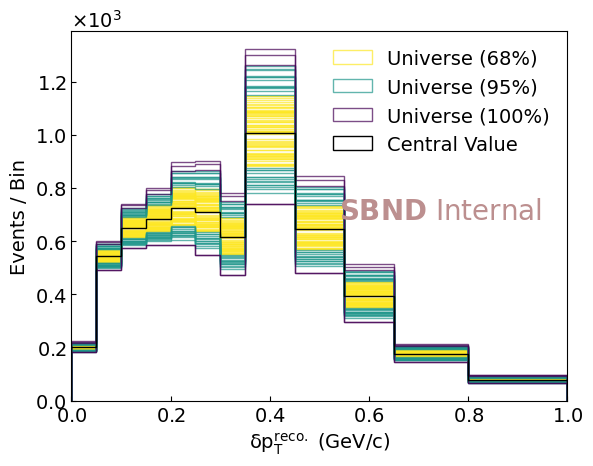

In [15]:
univ, cv, univ_bkgd, cv_bkgd = get_univ_rates(
    "rate",
    evtdf=evtdf,
    nudf=nudf,
    bkgd_subtract=True,
    return_bkgd=True,
    var_config=var_configs[0],
    syst_name=('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC'),
    n_univ=n_univ,
    xsec_unit=1.0,
    verbose=True,
)

plot_univ_hists(
    univ, cv, "", var_configs[0],
    ax_titles=['', '', ""],
)

univ, cv, univ_bkgd, cv_bkgd = get_univ_rates(
    "xsec",
    evtdf=evtdf,
    nudf=nudf,
    bkgd_subtract=True,
    return_bkgd=True,
    var_config=var_configs[0],
    syst_name=('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC'),
    n_univ=n_univ,
    xsec_unit=1.0,
    verbose=True,
)

plot_univ_hists(
    univ, cv, "", var_configs[0],
    ax_titles=['', '', ""],
)

plot_univ_hists(
    univ_bkgd, cv_bkgd, "", var_configs[0],
    ax_titles=['', '', ""],
)

In [ ]:
def _sanitize_matrix_pack(ret):
    out = {}
    for k in ('cov', 'cov_frac', 'corr'):
        out[k] = np.nan_to_num(np.asarray(ret[k], dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    return out


def frac_unc_from_pack(pack):
    return np.sqrt(np.maximum(np.diag(pack['cov_frac']), 0.0))


def inject_multiplied_mc_knob_weights(df, knobs, bundled_tag='Flux', n_univ=100, verbose=False):
    """Write ``(mc, bundled_tag, univ_i)`` as the product of per-knob weights (same universe index)."""
    if verbose:
        _log(f'inject multiplied weights ({bundled_tag}): {len(knobs)} knobs x {n_univ} universes on {len(df):,} events')
    t0 = time.time()
    df = df.copy()
    n_written = 0
    for uidx in tqdm(range(int(n_univ)), desc=f'inject {bundled_tag} product', disable=not verbose):
        w = np.ones(len(df), dtype=float)
        missing = False
        for knob in knobs:
            key = multicol_resolve_column_key(df, ('mc', knob, f'univ_{uidx}'))
            if key is None:
                missing = True
                break
            wi = np.asarray(df.loc[:, key], dtype=float)
            wi = np.nan_to_num(wi, nan=1.0, posinf=1.0, neginf=1.0)
            w *= wi
        if missing:
            continue
        col = ('mc', bundled_tag, f'univ_{uidx}', '', '', '', '')
        df.loc[:, col] = w
        n_written += 1
    if verbose:
        _log(f'  wrote {n_written}/{n_univ} multiplied-universe columns in {time.time() - t0:.1f}s')
    return df


def cov_pack_for_knob(evtdf, var_config, knob, n_univ, cov_type, bkgd_subtract, verbose=False):
    syst_name = ('mc', knob)
    univ, cv = get_univ_rates(
        cov_type,
        evtdf=evtdf,
        nudf=nudf,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=syst_name,
        n_univ=n_univ,
        xsec_unit=1.0,
        verbose=verbose,
    )
    pack = _sanitize_matrix_pack(get_covariance_matrix(univ, cv))
    return pack, univ, cv


def cov_pack_bundled(evtdf, var_config, syst_name, n_univ, cov_type, bkgd_subtract, verbose=False):
    """Single bundled multisim block (MCstat, or pre-merged Flux/G4)."""
    sk = resolve_bundled_syst_name(evtdf, syst_name)
    univ, cv = get_univ_rates(
        cov_type,
        evtdf=evtdf,
        nudf=nudf,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=sk,
        n_univ=n_univ,
        xsec_unit=1.0,
        verbose=verbose,
    )
    pack = _sanitize_matrix_pack(get_covariance_matrix(univ, cv))
    return pack, univ, cv


def cov_pack_multiplied(evtdf, var_config, knobs, n_univ, cov_type, bkgd_subtract, bundled_tag='Flux', verbose=False):
    df_w = inject_multiplied_mc_knob_weights(
        evtdf, knobs, bundled_tag=bundled_tag, n_univ=n_univ, verbose=verbose
    )
    univ, cv = get_univ_rates(
        cov_type,
        evtdf=df_w,
        nudf=nudf,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=('mc', bundled_tag),
        n_univ=n_univ,
        xsec_unit=1.0,
        verbose=verbose,
    )
    pack = _sanitize_matrix_pack(get_covariance_matrix(univ, cv))
    return pack, univ, cv


In [ ]:
# var_list = []
# for i in range(n_univ):
#     var = list(mc_evt_df.mc['reinteractions_neutron_Geant4'].univ_0)
#     var_list.append(var)

# var_list = np.array(var_list)
# plt.hist(var_list, bins=100)
# plt.yscale('log')
# plt.show()

In [ ]:
cov_type = "xsec"

In [ ]:
syst_dict = {}
results_by_syst_var = {}
t_all = time.time()

for sn in SYST_TYPES:
    knobs = syst_knob_names(sn)
    knob_mode = bool(knobs)
    _log(f'=== category {sn} ({len(knobs)} knobs) ===')
    t_cat = time.time()

    _log(f'dropping bad {sn} weights ...')
    t_clean = time.time()
    mc_evt_df = drop_bad_weights(evtdf_by_syst[sn], sn, knobs, n_univ)
    n_drop = len(evtdf_by_syst[sn]) - len(mc_evt_df)
    _log(f'{len(mc_evt_df):,} events after cleaning ({n_drop:,} dropped) in {time.time() - t_clean:.1f}s')
    if len(mc_evt_df) == 0:
        raise RuntimeError(f'no events left after weight cleaning for {sn}')

    syst_dict[sn] = {}
    if knob_mode:
        syst_dict[f'{sn}_by_knob'] = {}

    first_var_done = False

    for ivar, var_config in enumerate(tqdm(var_configs, desc=f'variables ({sn})')):
        vsn = var_config.var_save_name
        t_var = time.time()
        _log(f'--- {sn} variable [{ivar + 1}/{len(var_configs)}] {vsn} ---')

        if not knob_mode:
            verbose_knob = VERBOSE_UNIV_LOOP and ivar == 0
            try:
                pack, univ, cv = cov_pack_bundled(
                    mc_evt_df, var_config, sn, n_univ, cov_type, bkgd_subtract,
                    verbose=verbose_knob,
                )
            except Exception as ex:
                _log(f'  SKIP bundled {sn} for {vsn}: {ex}')
                continue
            fu = frac_unc_from_pack(pack)
            syst_dict[sn][vsn] = pack
            results_by_syst_var[(sn, vsn)] = {'bundled': pack}
            _log(
                f'  {sn}: mean frac unc={np.mean(fu):.4f}, max={np.max(fu):.4f}, '
                f'{time.time() - t_var:.1f}s'
            )
            if PLOT_FRAC_UNC_EACH_VAR:
                plot_frac_unc([fu], var_config, legends=[sn])
                plt.suptitle(f'{vsn}: {sn} fractional uncertainty', y=1.02)
                plt.tight_layout()
                plt.show()
            if PLOT_HEATMAP_FIRST_VAR and not first_var_done:
                plot_heatmap(
                    pack['cov_frac'],
                    var_config.bins,
                    plot_labels=[var_config.var_labels[1], var_config.var_labels[1], f'cov_frac ({sn})'],
                    plot=True,
                )
                plt.suptitle(f'{vsn} {sn} cov_frac')
                plt.tight_layout()
                plt.show()
                sk = resolve_bundled_syst_name(mc_evt_df, sn)
                _univ_title = f'{vsn} {sn} universes'
                plot_univ_hists(
                    univ, cv, sk, var_config,
                    ax_titles=['', '', _univ_title],
                    save_fig=SAVE_UNIV_HISTS,
                    save_name=univ_hist_save_name(sn, vsn, sn) if SAVE_UNIV_HISTS else None,
                )
                plt.suptitle(_univ_title)
                plt.tight_layout()
                plt.show()
                first_var_done = True
            continue

        per_knob = {}
        frac_unc_curves = []
        knob_labels = []

        for iknob, knob in enumerate(tqdm(knobs, desc=f'knobs {sn}/{vsn}', leave=True)):
            t_knob = time.time()
            verbose_knob = VERBOSE_UNIV_LOOP and (iknob == 0 or (iknob + 1) % 10 == 0)
            try:
                pack, univ, cv = cov_pack_for_knob(
                    mc_evt_df, var_config, knob, n_univ, cov_type, bkgd_subtract,
                    verbose=verbose_knob,
                )
            except Exception as ex:
                _log(f'  SKIP knob={knob}: {ex}')
                continue
            per_knob[knob] = pack
            fu = frac_unc_from_pack(pack)
            knob_labels.append(knob)
            frac_unc_curves.append(fu)
            _log(
                f'  knob [{iknob + 1}/{len(knobs)}] {knob}: '
                f'mean frac unc={np.mean(fu):.4f}, max={np.max(fu):.4f}, '
                f'{time.time() - t_knob:.1f}s'
            )
            do_univ_plot = PLOT_UNIV_EVERY_N_KNOBS and (iknob == 0 or (iknob + 1) % PLOT_UNIV_EVERY_N_KNOBS == 0)
            if do_univ_plot:
                _univ_title = f'{sn} / {vsn} / {knob}'
                plot_univ_hists(
                    univ, cv, ('mc', knob), var_config,
                    ax_titles=['', '', _univ_title],
                    save_fig=SAVE_UNIV_HISTS,
                    save_name=univ_hist_save_name(sn, vsn, knob) if SAVE_UNIV_HISTS else None,
                )
                plt.suptitle(_univ_title, y=1.02)
                plt.tight_layout()
                plt.show()

        if not per_knob:
            _log(f'  no knobs succeeded for {sn}/{vsn}')
            continue

        _log(f'  computing multiplied-weight total ({len(per_knob)} knobs) ...')
        t_tot = time.time()
        try:
            pack_total, univ_tot, cv_tot = cov_pack_multiplied(
                mc_evt_df, var_config, tuple(per_knob.keys()), n_univ, cov_type, bkgd_subtract,
                bundled_tag=sn, verbose=VERBOSE_UNIV_LOOP,
            )
        except Exception as ex:
            _log(f'  SKIP multiplied total for {sn}/{vsn}: {ex}')
            continue
        fu_tot = frac_unc_from_pack(pack_total)
        _log(
            f'  total (× weights): mean frac unc={np.mean(fu_tot):.4f}, max={np.max(fu_tot):.4f}, '
            f'{time.time() - t_tot:.1f}s'
        )

        syst_dict[sn][vsn] = pack_total
        syst_dict[f'{sn}_by_knob'][vsn] = per_knob
        results_by_syst_var[(sn, vsn)] = {'per_knob': per_knob, 'total_mult': pack_total}

        frac_unc_curves.append(fu_tot)
        knob_labels.append('total (weights ×)')
        if PLOT_FRAC_UNC_EACH_VAR:
            plot_frac_unc(frac_unc_curves, var_config, legends=knob_labels)
            plt.suptitle(f'{sn} / {vsn}: per-knob + total fractional uncertainty', y=1.02)
            plt.tight_layout()
            plt.show()
        if PLOT_HEATMAP_FIRST_VAR and not first_var_done:
            plot_heatmap(
                pack_total['cov_frac'],
                var_config.bins,
                plot_labels=[var_config.var_labels[1], var_config.var_labels[1], 'cov_frac (total)'],
                plot=True,
            )
            plt.suptitle(f'{sn} / {vsn} total cov_frac')
            plt.tight_layout()
            plt.show()
            _univ_title = f'{sn} / {vsn} total multiplied weights'
            plot_univ_hists(
                univ_tot, cv_tot, ('mc', sn), var_config,
                ax_titles=['', '', _univ_title],
                save_fig=SAVE_UNIV_HISTS,
                save_name=univ_hist_save_name(sn, vsn, 'total-mult') if SAVE_UNIV_HISTS else None,
            )
            plt.suptitle(_univ_title)
            plt.tight_layout()
            plt.show()
            first_var_done = True

        _log(f'  done {sn}/{vsn} in {time.time() - t_var:.1f}s')

    _log(f'FINISHED {sn}: {len(syst_dict[sn])} variables in {time.time() - t_cat:.1f}s')
    _log(f'{sn} variables: ' + ', '.join(sorted(syst_dict[sn].keys())))

_log(f'ALL CATEGORIES done in {time.time() - t_all:.1f}s')


In [ ]:
_log('writing NPZ(s) ...')
save_neutrino_multisim_npzs(syst_dict, SYST_DISK_ROOT)
for sn in SYST_TYPES:
    if not syst_dict.get(sn):
        continue
    from analysis_village.numucc_1p0pi.syst_disk_layout import (
        SUB_MCSTAT, FILE_MCSTAT, SUB_FLUX, FILE_FLUX, SUB_G4, FILE_G4,
    )
    _paths = {
        'MCstat': (SUB_MCSTAT, FILE_MCSTAT),
        'Flux': (SUB_FLUX, FILE_FLUX),
        'G4': (SUB_G4, FILE_G4),
        'GENIE': (SUB_GENIE, FILE_GENIE),
    }
    sub, fname = _paths[sn]
    npz_path = path.join(normalized_root(SYST_DISK_ROOT), sub, fname)
    _log(f'  wrote {npz_path}')

categories_present = [sn for sn in SYST_TYPES if syst_dict.get(sn)]
knob_sidecars = [f'{sn}_by_knob' for sn in SYST_TYPES if syst_dict.get(f'{sn}_by_knob')]
var_names = set()
for sn in categories_present:
    var_names.update(syst_dict[sn].keys())

manifest = {
    'schema': 'numucc_multisim_covariance_v1',
    'description': (
        'Notebook multisim syst: per-knob packs under *_by_knob for Flux/G4; combined '
        'Flux/G4 entry uses multiplied per-universe weights across knobs. MCstat is bundled only.'
    ),
    'mc_df_stage': 'final',
    'var_set': 'notebook',
    'syst_types_run': list(SYST_TYPES),
    'categories_present': categories_present,
    'knob_breakdown_sidecars': knob_sidecars,
    'variables': sorted(var_names),
    'knob_total_method': {sn: 'multiply_univ_weights' for sn in ('Flux', 'G4') if sn in categories_present},
    'n_univ': n_univ,
    'bkgd_subtract': bkgd_subtract,
    'cov_type': cov_type,
    'knobs': {sn: list(syst_knob_names(sn)) for sn in SYST_TYPES if syst_knob_names(sn)},
}
manifest_path = path.join(normalized_root(SYST_DISK_ROOT), 'covariance_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
_log('wrote ' + manifest_path)


In [ ]:
# Optional: inspect one variable (matrices + per-bin fractional uncertainty)
INSPECT_SYST = SYST_TYPES[-1]
inspect_var = var_configs[-1].var_save_name
pack = syst_dict[INSPECT_SYST][inspect_var]
vc = next(v for v in var_configs if v.var_save_name == inspect_var)

for matrix_type in ('cov', 'cov_frac', 'corr'):
    plot_heatmap(
        pack[matrix_type],
        vc.bins,
        plot_labels=[vc.var_labels[1], vc.var_labels[1], matrix_type],
        plot=True,
        save_fig=False,
    )
    plt.show()

print(f'{INSPECT_SYST} sqrt(diag(cov_frac)):', frac_unc_from_pack(pack))
